# SAE-анализ галлюцинаций 

## 1. Установка

In [ ]:
!pip install -q sae-lens datasets transformers accelerate
!pip install -q xgboost scikit-learn scipy seaborn matplotlib tqdm

print("✅ Установка завершена")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.9/290.9 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 945.3/945.3 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.1/274.1 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.6/236.6 kB 28.9 MB/s eta 0:00:00
✅ Установка завершена


## 2. Импорты и конфигурация

In [ ]:
import os, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from scipy import stats
from scipy.stats import mannwhitneyu
from sklearn.linear_model import LogisticRegression, ElasticNet
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              precision_score, recall_score, classification_report)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost недоступен, используем GradientBoosting")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Устройство: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

plt.style.use("seaborn-v0_8-whitegrid")
DPI = 150

🖥️  Устройство: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 3. Конфигурация

In [ ]:
# ─── ПАРАМЕТРЫ ────────────────────────────────────────────
BEST_LAYER    = 13          
AGGREGATION   = "last_token"
NUM_SAMPLES   = 1634
RANDOM_STATE  = 42
TEST_SIZE     = 0.2
BATCH_SIZE_HIDDEN = 8
BATCH_SIZE_SAE    = 256
SAE_WIDTH     = "65k"

CANDIDATE_LAYERS = [12, 15, 17, 20, 22, 25] 

TOP_K_VALUES  = [10, 20, 50, 100, 200, 500]


HIDDEN_STATES_PATH   = "hidden_states_part2.npz"
SAE_ACTS_PATH_TMPL   = "sae_acts_layer{}.npz"  

PART1_RESULTS = {
    "Zero-shot EN":        0.7389, "Zero-shot RU":        0.7492,
    "Few-shot EN":         0.7300, "Few-shot RU":         0.7350,
    "CoT EN":              0.7450, "CoT RU":              0.7400,
    "Self-Cons. EN":       0.7577, "Self-Cons. RU":       0.7467,
    "Reference-based":     0.8932,
}
PART2_RESULTS = {
    "Linear Probe (raw)":  0.7554,
    "MLP Probe (raw)":     0.7798,
}

print("✅ Конфигурация загружена")
print(f"   Кандидаты слоёв: {CANDIDATE_LAYERS}")

✅ Конфигурация загружена
   Кандидаты слоёв: [12, 15, 17, 20, 22, 25]


## 4. Загрузка данных

In [ ]:
with open('/content/truthfulqa_pairs.json', encoding='utf-8') as f:
    pairs = json.load(f)

texts      = [p['text']     for p in pairs]
questions  = [p['question'] for p in pairs]
categories = [p['category'] for p in pairs]
labels     = np.array([p['label'] for p in pairs])

_hs = np.load('/content/hidden_states_unified.npz')
strat_map = {
    'last_token':   _hs['last_token'],
    'mean_pooling': _hs['mean_pooling'],
    'answer_mean':  _hs['answer_mean'],
}

hs_best = strat_map[AGGREGATION][:, BEST_LAYER, :].astype(np.float32)
print(f'Загружено: {len(texts)} примеров, hs_best: {hs_best.shape}')

Загружено: 1634 примеров, hs_best: (1634, 2304)


## 5. Загрузка SAE для нескольких слоёв

In [ ]:
from sae_lens import SAE

def load_sae(layer, width="16k"):
    try:
        sae, cfg, _ = SAE.from_pretrained(
            release=f"gemma-scope-2b-pt-res-canonical",
            sae_id=f"layer_{layer}/width_{width}/canonical",
        )
        return sae.to(torch.float32).to(device), cfg
    except Exception as e:
        print(f"  ⚠️ Слой {layer}: {e}")
        return None, None

def extract_sae_acts(hs_layer, sae, batch_size=256):
    """hs_layer: (n, hidden_size) → (n, n_features) float16"""
    n, acts = len(hs_layer), []
    sae_dev = next(sae.parameters()).device
    for off in range(0, n, batch_size):
        b = torch.tensor(hs_layer[off:off+batch_size].astype(np.float32),
                         dtype=torch.float32, device=sae_dev)
        with torch.no_grad():
            try:
                fa = sae.encode(b)
            except Exception:
                out = sae(b); fa = out.feature_acts if hasattr(out,"feature_acts") else out[1]
        acts.append(fa.cpu().numpy().astype(np.float16))
    return np.vstack(acts)

layer_sae_acts = {} 

for layer in CANDIDATE_LAYERS:
    path = SAE_ACTS_PATH_TMPL.format(layer)
    if os.path.exists(path):
        print(f"📂 Слой {layer}: загружаем кэш {path}")
        layer_sae_acts[layer] = np.load(path)["activations"]
    else:
        print(f"🔄 Слой {layer}: загружаем SAE...")
        sae_l, cfg_l = load_sae(layer)
        if sae_l is None:
            continue
        hs_l = strat_map[AGGREGATION][:, layer, :]  # (1000, 2304)
        acts = extract_sae_acts(hs_l.astype(np.float32), sae_l)
        np.savez_compressed(path, activations=acts, labels=labels)
        layer_sae_acts[layer] = acts
        del sae_l; torch.cuda.empty_cache()
        print(f"  ✅ Сохранено: {acts.shape}, разреж.={((acts==0).mean()):.1%}")

print(f"\n✅ Готово: SAE-активации для слоёв {list(layer_sae_acts.keys())}")
N_FEATURES = next(iter(layer_sae_acts.values())).shape[1]
print(f"   Фичей на слой: {N_FEATURES}")

🔄 Слой 12: загружаем SAE...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


layer_12/width_16k/average_l0_82/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

/tmp/ipykernel_8283/886225793.py:5: DeprecationWarning: Unpacking SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae, cfg, _ = SAE.from_pretrained(


  ✅ Сохранено: (1634, 16384), разреж.=99.4%
🔄 Слой 15: загружаем SAE...


...

  ✅ Сохранено: (1634, 16384), разреж.=99.7%
🔄 Слой 22: загружаем SAE...


layer_22/width_16k/average_l0_72/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

  ✅ Сохранено: (1634, 16384), разреж.=99.6%
🔄 Слой 25: загружаем SAE...


layer_25/width_16k/average_l0_116/params(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

  ✅ Сохранено: (1634, 16384), разреж.=99.5%

✅ Готово: SAE-активации для слоёв [12, 15, 17, 20, 22, 25]
   Фичей на слой: 16384


## 6. Улучшенный отбор фичей


In [ ]:
from statsmodels.stats.multitest import multipletests

def analyze_features(sae_acts, labels, layer_name="layer"):
    """Возвращает DataFrame с ранжированными фичами."""
    acts_f32 = sae_acts.astype(np.float32)
    mask_c, mask_h = labels == 1, labels == 0
    acts_c, acts_h = acts_f32[mask_c], acts_f32[mask_h]
    n_feat = acts_f32.shape[1]

    mean_c = acts_c.mean(0);   mean_h = acts_h.mean(0)
    diff   = mean_h - mean_c;  abs_diff = np.abs(diff)
    freq_c = (acts_c > 0).mean(0); freq_h = (acts_h > 0).mean(0)

    active = (mean_c + mean_h) > 1e-6
    p_vals = np.ones(n_feat)
    for i in tqdm(range(n_feat), desc=f"Mann-Whitney [{layer_name}]", miniters=n_feat//20):
        if active[i]:
            try:
                _, p = mannwhitneyu(acts_h[:,i], acts_c[:,i], alternative="two-sided")
                p_vals[i] = p
            except: pass

    reject_fdr, p_fdr, _, _ = multipletests(p_vals, method="fdr_bh", alpha=0.05)

    print(f"  Вычисляем Mutual Information [{layer_name}]...")
    mi_scores = mutual_info_classif(acts_f32, labels, discrete_features=False,
                                    random_state=RANDOM_STATE, n_neighbors=3)

    def norm01(x):
        mn, mx = x.min(), x.max()
        return (x - mn) / (mx - mn + 1e-12)

    combo_score = norm01(abs_diff) * 0.4 + norm01(mi_scores) * 0.4 + norm01(1 - p_fdr) * 0.2

    df = pd.DataFrame({
        "feature_id":   np.arange(n_feat),
        "mean_correct": mean_c, "mean_halluc": mean_h,
        "diff":         diff,   "abs_diff":    abs_diff,
        "freq_correct": freq_c, "freq_halluc": freq_h,
        "p_value":      p_vals, "p_fdr":       p_fdr,
        "significant_fdr": reject_fdr,
        "mi_score":     mi_scores,
        "combo_score":  combo_score,
        "layer":        layer_name,
    }).sort_values("combo_score", ascending=False).reset_index(drop=True)

    print(f"  FDR-значимых фичей: {reject_fdr.sum()} / {n_feat}")
    return df

layer_dfs = {}
for layer, acts in layer_sae_acts.items():
    print(f"\n📐 Анализ слоя {layer}...")
    layer_dfs[layer] = analyze_features(acts, labels, layer_name=str(layer))



📐 Анализ слоя 12...


Mann-Whitney [12]:   0%|          | 0/16384 [00:00<?, ?it/s]

  Вычисляем Mutual Information [12]...
  FDR-значимых фичей: 205 / 16384

📐 Анализ слоя 15...


Mann-Whitney [15]:   0%|          | 0/16384 [00:00<?, ?it/s]

  Вычисляем Mutual Information [15]...
  FDR-значимых фичей: 89 / 16384

📐 Анализ слоя 17...


...

  Вычисляем Mutual Information [20]...
  FDR-значимых фичей: 105 / 16384

📐 Анализ слоя 22...


Mann-Whitney [22]:   0%|          | 0/16384 [00:00<?, ?it/s]

  Вычисляем Mutual Information [22]...
  FDR-значимых фичей: 113 / 16384

📐 Анализ слоя 25...


Mann-Whitney [25]:   0%|          | 0/16384 [00:00<?, ?it/s]

  Вычисляем Mutual Information [25]...
  FDR-значимых фичей: 141 / 16384


## 7. Выбор лучшего слоя SAE

Для каждого слоя-кандидата обучаем LogReg на Top-100 фичей и сравниваем через 5-fold CV.


In [ ]:
def cv_score_topk(sae_acts, df_feats, k=100, cv=5):
    """5-fold CV accuracy на top-k фичах по combo_score."""
    top_ids = df_feats.head(k)["feature_id"].values.astype(int)
    X = sae_acts.astype(np.float32)[:, top_ids]
    scaler = RobustScaler() 
    X_sc = scaler.fit_transform(X)
    clf = LogisticRegression(solver="lbfgs", max_iter=2000, C=0.1,
                              random_state=RANDOM_STATE, class_weight="balanced")
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(clf, X_sc, labels, cv=skf, scoring="accuracy")
    return scores.mean(), scores.std()

print("🔍 Выбор лучшего слоя SAE (5-fold CV, top-100 фичей):\n")
layer_cv_results = {}
for layer in layer_sae_acts:
    mean_cv, std_cv = cv_score_topk(layer_sae_acts[layer], layer_dfs[layer], k=100, cv=5)
    layer_cv_results[layer] = {"mean": mean_cv, "std": std_cv}
    print(f"  Слой {layer:2d}: CV accuracy = {mean_cv:.4f} ± {std_cv:.4f}")

BEST_SAE_LAYER = max(layer_cv_results, key=lambda l: layer_cv_results[l]["mean"])
print(f"\n🏆 Лучший слой SAE: {BEST_SAE_LAYER} "
      f"(CV acc = {layer_cv_results[BEST_SAE_LAYER]['mean']:.4f})")

best_sae_acts = layer_sae_acts[BEST_SAE_LAYER].astype(np.float32)
best_df_feats = layer_dfs[BEST_SAE_LAYER]

🔍 Выбор лучшего слоя SAE (5-fold CV, top-100 фичей):

  Слой 12: CV accuracy = 0.7093 ± 0.0088
  Слой 15: CV accuracy = 0.6995 ± 0.0152
  Слой 17: CV accuracy = 0.7472 ± 0.0135
  Слой 20: CV accuracy = 0.7368 ± 0.0168
  Слой 22: CV accuracy = 0.7332 ± 0.0239
  Слой 25: CV accuracy = 0.7338 ± 0.0242

🏆 Лучший слой SAE: 17 (CV acc = 0.7472)


## 8. Полный набор классификаторов на SAE-фичах


In [ ]:
X_full = best_sae_acts                  
y      = labels
all_feature_ids_ranked = best_df_feats["feature_id"].values.astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_full, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

def get_top_k(X_tr, X_te, k):
    ids = all_feature_ids_ranked[:k]
    return X_tr[:,ids], X_te[:,ids], ids

def evaluate(name, clf, X_tr, X_te, y_tr, y_te, scale=True):
    if scale:
        sc = RobustScaler()
        Xtr_sc = sc.fit_transform(X_tr)
        Xte_sc = sc.transform(X_te)
    else:
        Xtr_sc, Xte_sc = X_tr, X_te
    clf.fit(Xtr_sc, y_tr)
    yp   = clf.predict(Xte_sc)
    yp_p = clf.predict_proba(Xte_sc)[:,1] if hasattr(clf,"predict_proba") else None
    acc  = accuracy_score(y_te, yp)
    f1   = f1_score(y_te, yp, average="macro")
    auc  = roc_auc_score(y_te, yp_p) if yp_p is not None else float("nan")
    print(f"  {name:45s}  acc={acc:.4f}  f1={f1:.4f}  auc={auc:.4f}")
    return {"name": name, "accuracy": acc, "f1": f1, "auc": auc}

results = []
print(f"{'='*75}")
print(f"Модель {'':<38}  acc      f1       auc")
print(f"{'='*75}")

lr_all = LogisticRegression(solver="lbfgs", max_iter=2000, C=1.0,
                             random_state=RANDOM_STATE, class_weight="balanced")
results.append(evaluate("LogReg C=1.0 (all 16k)", lr_all, X_tr, X_te, y_tr, y_te))

lr_enet = LogisticRegression(solver="saga", max_iter=3000, penalty="elasticnet",
                              l1_ratio=0.5, C=0.01,
                              random_state=RANDOM_STATE, class_weight="balanced")
results.append(evaluate("ElasticNet LogReg C=0.01 (all 16k)", lr_enet, X_tr, X_te, y_tr, y_te))

for k in TOP_K_VALUES:
    Xtr_k, Xte_k, _ = get_top_k(X_tr, X_te, k)
    for C in [0.1, 1.0]:
        clf = LogisticRegression(solver="lbfgs", max_iter=2000, C=C,
                                  random_state=RANDOM_STATE, class_weight="balanced")
        results.append(evaluate(f"LogReg C={C} (top-{k})", clf, Xtr_k, Xte_k, y_tr, y_te))

for k in [50, 100, 200]:
    Xtr_k, Xte_k, _ = get_top_k(X_tr, X_te, k)
    mlp = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500,
                        random_state=RANDOM_STATE, early_stopping=True,
                        validation_fraction=0.15, alpha=0.01)
    results.append(evaluate(f"MLP (256,128) (top-{k})", mlp, Xtr_k, Xte_k, y_tr, y_te))

for k in [100, 200]:
    Xtr_k, Xte_k, _ = get_top_k(X_tr, X_te, k)
    if XGBOOST_AVAILABLE:
        xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             use_label_encoder=False, eval_metric="logloss",
                             random_state=RANDOM_STATE, verbosity=0)
    else:
        xgb = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                          learning_rate=0.05, random_state=RANDOM_STATE)
    results.append(evaluate(f"XGBoost (top-{k})", xgb, Xtr_k, Xte_k, y_tr, y_te, scale=False))

for k in [100, 200]:
    Xtr_k, Xte_k, _ = get_top_k(X_tr, X_te, k)
    rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5,
                                 random_state=RANDOM_STATE, class_weight="balanced",
                                 n_jobs=-1)
    results.append(evaluate(f"RandomForest (top-{k})", rf, Xtr_k, Xte_k, y_tr, y_te, scale=False))

print(f"{'='*75}")
df_results = pd.DataFrame(results).sort_values("accuracy", ascending=False)
print(f"\n🏆 Топ-5 по accuracy:")
print(df_results.head(5)[["name","accuracy","f1","auc"]].to_string(index=False))

Модель                                         acc      f1       auc
  LogReg C=1.0 (all 16k)                         acc=0.6789  f1=0.6786  auc=0.7668
  ElasticNet LogReg C=0.01 (all 16k)             acc=0.7462  f1=0.7456  auc=0.8247
  LogReg C=0.1 (top-10)                          acc=0.7156  f1=0.7104  auc=0.7759
  LogReg C=1.0 (top-10)                          acc=0.7125  f1=0.7070  auc=0.7757
  LogReg C=0.1 (top-20)                          acc=0.7370  f1=0.7332  auc=0.7814
  LogReg C=1.0 (top-20)                          acc=0.7278  f1=0.7249  auc=0.7807
  LogReg C=0.1 (top-50)                          acc=0.7187  f1=0.7179  auc=0.8059
  LogReg C=1.0 (top-50)                          acc=0.7125  f1=0.7118  auc=0.8033
  LogReg C=0.1 (top-100)                         acc=0.7523  f1=0.7520  auc=0.8247
  LogReg C=1.0 (top-100)                         acc=0.7523  f1=0.7520  auc=0.8256
  LogReg C=0.1 (top-200)                         acc=0.7554  f1=0.7552  auc=0.8386
  LogReg C=1.0 (to

## 9. Ансамбль лучших моделей

Объединяем top-3 модели в `VotingClassifier` (soft voting) для повышения качества.


In [ ]:
top3 = df_results.head(3)
print(f"Топ-3 модели для ансамбля:")
print(top3[["name","accuracy"]].to_string(index=False))

best_k_row = df_results.iloc[0]
best_name  = best_k_row["name"]

import re
k_match = re.search(r"top-(\d+)", best_name)
best_k_ens = int(k_match.group(1)) if k_match else 100
print(f"\nОптимальный K = {best_k_ens}")

Xtr_ens, Xte_ens, ens_ids = get_top_k(X_tr, X_te, best_k_ens)
sc_ens = RobustScaler()
Xtr_ens_sc = sc_ens.fit_transform(Xtr_ens)
Xte_ens_sc = sc_ens.transform(Xte_ens)

e1 = LogisticRegression(solver="lbfgs", max_iter=2000, C=0.1,
                         random_state=RANDOM_STATE, class_weight="balanced")
e2 = MLPClassifier(hidden_layer_sizes=(256,128), max_iter=500,
                    random_state=RANDOM_STATE, early_stopping=True, alpha=0.01)
if XGBOOST_AVAILABLE:
    e3 = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        use_label_encoder=False, eval_metric="logloss",
                        random_state=RANDOM_STATE, verbosity=0)
else:
    e3 = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                     learning_rate=0.05, random_state=RANDOM_STATE)

e1.fit(Xtr_ens_sc, y_tr)
e2.fit(Xtr_ens_sc, y_tr)
e3.fit(Xtr_ens, y_tr)  

p1 = e1.predict_proba(Xte_ens_sc)
p2 = e2.predict_proba(Xte_ens_sc)
p3 = e3.predict_proba(Xte_ens)

weights = [0.35, 0.35, 0.30]
p_ens   = weights[0]*p1 + weights[1]*p2 + weights[2]*p3
y_ens   = (p_ens[:,1] > 0.5).astype(int)

acc_ens = accuracy_score(y_te, y_ens)
f1_ens  = f1_score(y_te, y_ens, average="macro")
auc_ens = roc_auc_score(y_te, p_ens[:,1])
print(f"\n🎯 Ensemble (soft voting, top-{best_k_ens}):")
print(f"   Accuracy = {acc_ens:.4f}")
print(f"   F1-macro = {f1_ens:.4f}")
print(f"   ROC-AUC  = {auc_ens:.4f}")

results.append({"name": f"Ensemble (soft voting, top-{best_k_ens})",
                "accuracy": acc_ens, "f1": f1_ens, "auc": auc_ens})

Топ-3 модели для ансамбля:
                  name  accuracy
     XGBoost (top-200)  0.764526
LogReg C=0.1 (top-500)  0.761468
     XGBoost (top-100)  0.755352

Оптимальный K = 200

🎯 Ensemble (soft voting, top-200):
   Accuracy = 0.7859
   F1-macro = 0.7850
   ROC-AUC  = 0.8557


## 10. SAE-фичи + Raw Hidden States (гибридный подход)

**Идея:** SAE-фичи дают интерпретируемые признаки, raw HS — плотное представление.  
Объединяем их для максимального качества.


In [ ]:
hs_raw_layer = strat_map[AGGREGATION][:, BEST_SAE_LAYER, :].astype(np.float32)  # (1000, 2304)

top_sae_ids = all_feature_ids_ranked[:200]
sae_top200  = best_sae_acts[:, top_sae_ids]

X_hybrid = np.hstack([hs_raw_layer, sae_top200]) 
print(f"Hybrid shape: {X_hybrid.shape}")

Xtr_h, Xte_h, ytr_h, yte_h = train_test_split(
    X_hybrid, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

sc_h = RobustScaler()
Xtr_h_sc = sc_h.fit_transform(Xtr_h)
Xte_h_sc = sc_h.transform(Xte_h)

pca = PCA(n_components=200, random_state=RANDOM_STATE)
Xtr_h_pca = pca.fit_transform(Xtr_h_sc)
Xte_h_pca = pca.transform(Xte_h_sc)
print(f"PCA объясняет {pca.explained_variance_ratio_.sum():.1%} дисперсии")

results_hybrid = []
print(f"\n{'='*65}")
print(f"Модель {'':<32}  acc      f1       auc")
print(f"{'='*65}")

for name, X_tr_in, X_te_in in [
    ("Hybrid (raw+SAE-200) direct", Xtr_h_sc, Xte_h_sc),
    ("Hybrid (raw+SAE-200) PCA-200", Xtr_h_pca, Xte_h_pca),
]:
    for C in [0.1, 1.0]:
        clf = LogisticRegression(solver="lbfgs", max_iter=2000, C=C,
                                  random_state=RANDOM_STATE, class_weight="balanced")
        clf.fit(X_tr_in, y_tr)
        yp  = clf.predict(X_te_in)
        ypp = clf.predict_proba(X_te_in)[:,1]
        acc = accuracy_score(y_te, yp)
        f1  = f1_score(y_te, yp, average="macro")
        auc = roc_auc_score(y_te, ypp)
        n_  = f"{name} C={C}"
        print(f"  {n_:45s}  acc={acc:.4f}  f1={f1:.4f}  auc={auc:.4f}")
        results_hybrid.append({"name": n_, "accuracy": acc, "f1": f1, "auc": auc})

mlp_h = MLPClassifier(hidden_layer_sizes=(512,256,128), max_iter=500,
                       random_state=RANDOM_STATE, early_stopping=True,
                       validation_fraction=0.15, alpha=0.005)
mlp_h.fit(Xtr_h_pca, y_tr)
yp_m  = mlp_h.predict(Xte_h_pca)
ypp_m = mlp_h.predict_proba(Xte_h_pca)[:,1]
acc_m = accuracy_score(y_te, yp_m)
f1_m  = f1_score(y_te, yp_m, average="macro")
auc_m = roc_auc_score(y_te, ypp_m)
print(f"  {'MLP (512,256,128) on Hybrid PCA-200':45s}  acc={acc_m:.4f}  f1={f1_m:.4f}  auc={auc_m:.4f}")
results_hybrid.append({"name":"MLP Hybrid PCA-200","accuracy":acc_m,"f1":f1_m,"auc":auc_m})
print(f"{'='*65}")

df_hybrid = pd.DataFrame(results_hybrid).sort_values("accuracy", ascending=False)
print(f"\n🏆 Лучший гибридный метод:")
print(df_hybrid.head(1).to_string(index=False))
results.extend(results_hybrid)

Hybrid shape: (1634, 2504)
PCA объясняет 78.7% дисперсии

Модель                                   acc      f1       auc
  Hybrid (raw+SAE-200) direct C=0.1              acc=0.7156  f1=0.7149  auc=0.8300
  Hybrid (raw+SAE-200) direct C=1.0              acc=0.7156  f1=0.7154  auc=0.8163
  Hybrid (raw+SAE-200) PCA-200 C=0.1             acc=0.7370  f1=0.7359  auc=0.8253
  Hybrid (raw+SAE-200) PCA-200 C=1.0             acc=0.7370  f1=0.7361  auc=0.8245
  MLP (512,256,128) on Hybrid PCA-200            acc=0.7278  f1=0.7273  auc=0.8283

🏆 Лучший гибридный метод:
                              name  accuracy       f1      auc
Hybrid (raw+SAE-200) PCA-200 C=0.1  0.737003 0.735914 0.825303


## 11. Финальная оценка через Stratified 10-Fold CV

In [ ]:
df_all_results = pd.DataFrame(results).sort_values("accuracy", ascending=False)
best_model_row = df_all_results.iloc[0]
print(f"🏆 Лучшая модель (hold-out): {best_model_row['name']}")
print(f"   Accuracy = {best_model_row['accuracy']:.4f}")

best_k_final = 200 
top_final_ids = all_feature_ids_ranked[:best_k_final]
X_final = best_sae_acts[:, top_final_ids]

skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(solver="lbfgs", max_iter=2000, C=0.1,
                                random_state=RANDOM_STATE, class_weight="balanced"))
])
cv_scores = cross_val_score(pipe, X_final, y, cv=skf10, scoring="accuracy")
print(f"\n📊 10-Fold CV (LogReg C=0.1, top-{best_k_final}):")
print(f"   Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   Folds: {np.round(cv_scores, 4)}")
print(f"   Min/Max: {cv_scores.min():.4f} / {cv_scores.max():.4f}")

🏆 Лучшая модель (hold-out): Ensemble (soft voting, top-200)
   Accuracy = 0.7859

📊 10-Fold CV (LogReg C=0.1, top-200):
   Mean: 0.7448 ± 0.0295
   Folds: [0.7866 0.7195 0.7439 0.7744 0.7055 0.7362 0.7914 0.7362 0.7485 0.7055]
   Min/Max: 0.7055 / 0.7914


## 12. Визуализации

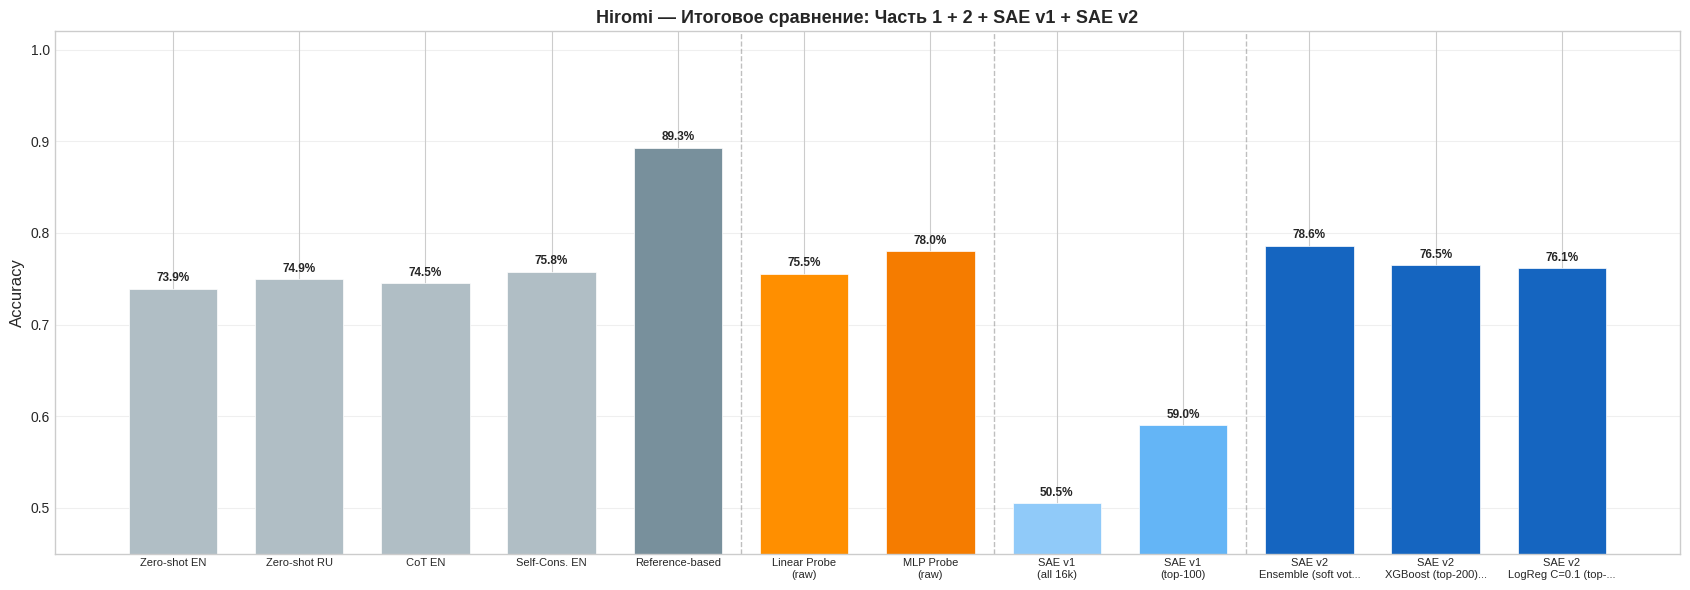

✅ Сохранено: hiromi_v2_comparison.png


In [ ]:
all_methods_final = {
    "Zero-shot EN":       PART1_RESULTS["Zero-shot EN"],
    "Zero-shot RU":       PART1_RESULTS["Zero-shot RU"],
    "CoT EN":             PART1_RESULTS["CoT EN"],
    "Self-Cons. EN":      PART1_RESULTS["Self-Cons. EN"],
    "Reference-based":    PART1_RESULTS["Reference-based"],
    "Linear Probe\n(raw)": PART2_RESULTS["Linear Probe (raw)"],
    "MLP Probe\n(raw)":    PART2_RESULTS["MLP Probe (raw)"],
    "SAE v1\n(all 16k)": 0.5050,
    "SAE v1\n(top-100)": 0.5900,
}

top3_v2 = df_all_results.head(3)
for _, row in top3_v2.iterrows():
    label = f"SAE v2\n{row['name'][:18]}..."
    all_methods_final[label] = row["accuracy"]

colors_final = (
    ["#B0BEC5"] * 4 +         
    ["#78909C"] * 1 +         
    ["#FF8F00", "#F57C00"] +  
    ["#90CAF9", "#64B5F6"] +  
    ["#1565C0"] * 3            
)

fig, ax = plt.subplots(figsize=(17, 6))
x_labels = list(all_methods_final.keys())
x_vals   = list(all_methods_final.values())
bars = ax.bar(x_labels, x_vals, color=colors_final[:len(x_labels)],
              edgecolor="white", linewidth=0.5, width=0.7)
for bar, val in zip(bars, x_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{val:.1%}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
ax.axvline(4.5,  color="gray", ls="--", alpha=0.5, lw=1)
ax.axvline(6.5,  color="gray", ls="--", alpha=0.5, lw=1)
ax.axvline(8.5,  color="gray", ls="--", alpha=0.5, lw=1)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Hiromi — Итоговое сравнение: Часть 1 + 2 + SAE v1 + SAE v2",
             fontsize=13, fontweight="bold")
ax.set_ylim(0.45, 1.02)
ax.grid(True, axis="y", alpha=0.3)
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.savefig("hiromi_v2_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✅ Сохранено: hiromi_v2_comparison.png")

/tmp/ipykernel_8283/2614675912.py:19: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_8283/2614675912.py:20: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.savefig("sae_v2_layer_comparison.png", dpi=DPI, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


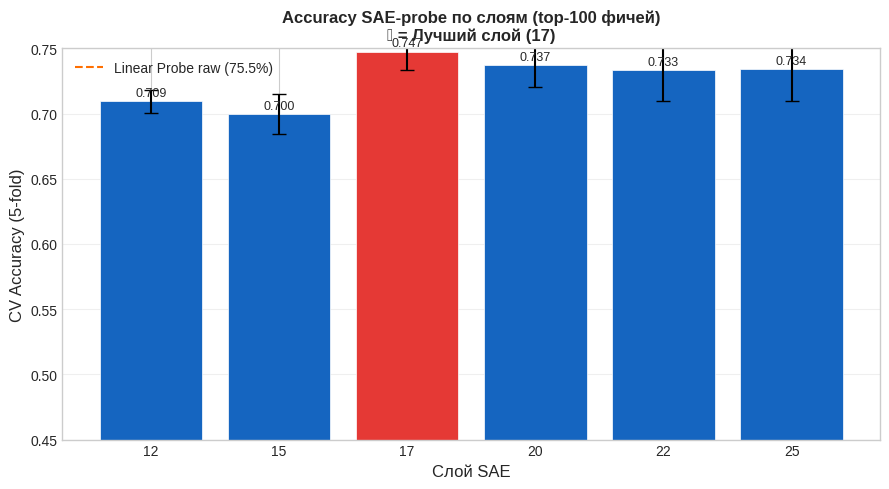

✅ Сохранено: sae_v2_layer_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
layers_plot = sorted(layer_cv_results.keys())
means = [layer_cv_results[l]["mean"] for l in layers_plot]
stds  = [layer_cv_results[l]["std"]  for l in layers_plot]
colors_l = ["#E53935" if l == BEST_SAE_LAYER else "#1565C0" for l in layers_plot]

ax.bar([str(l) for l in layers_plot], means, yerr=stds,
       color=colors_l, capsize=5, edgecolor="white", linewidth=0.5)
ax.axhline(PART2_RESULTS["Linear Probe (raw)"], color="#FF6F00", ls="--",
           lw=1.5, label=f"Linear Probe raw ({PART2_RESULTS['Linear Probe (raw)']:.1%})")
ax.set_xlabel("Слой SAE", fontsize=12)
ax.set_ylabel("CV Accuracy (5-fold)", fontsize=12)
ax.set_title(f"Accuracy SAE-probe по слоям (top-100 фичей)\n🔴 = Лучший слой ({BEST_SAE_LAYER})",
             fontsize=12, fontweight="bold")
for i, (l, m) in enumerate(zip(layers_plot, means)):
    ax.text(i, m+0.002, f"{m:.3f}", ha="center", va="bottom", fontsize=9)
ax.legend(); ax.set_ylim(0.45, 0.75); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("sae_v2_layer_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✅ Сохранено: sae_v2_layer_comparison.png")


Строим кривую v2 (RobustScaler + LogReg C=0.1)...


  0%|          | 0/9 [00:00<?, ?it/s]

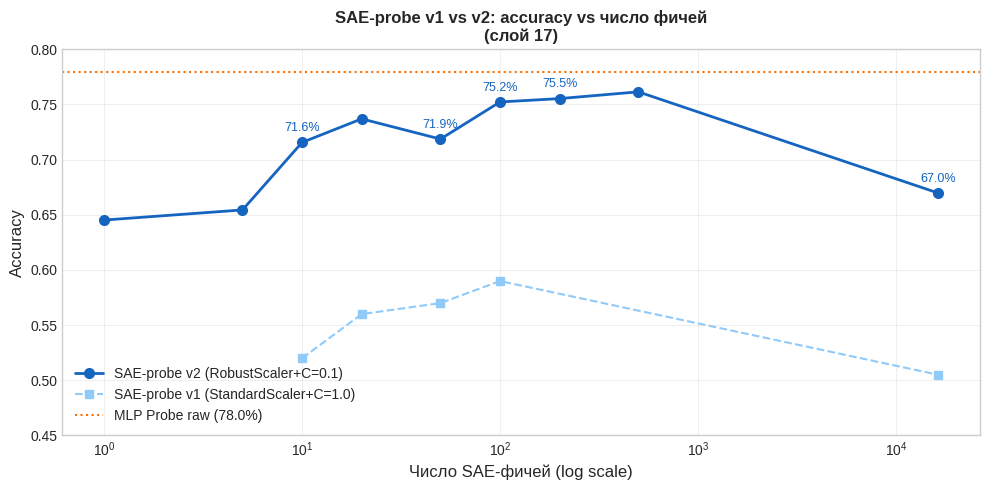

✅ Сохранено: sae_v2_vs_v1_curve.png


In [ ]:
k_vals_plot = [1, 5, 10, 20, 50, 100, 200, 500, N_FEATURES]
k_vals_plot = [k for k in k_vals_plot if k <= N_FEATURES]

accs_v2 = []
print("Строим кривую v2 (RobustScaler + LogReg C=0.1)...")
for k in tqdm(k_vals_plot):
    Xtr_k, Xte_k, _ = get_top_k(X_tr, X_te, k)
    sc = RobustScaler(); Xtr_sc = sc.fit_transform(Xtr_k); Xte_sc = sc.transform(Xte_k)
    clf = LogisticRegression(solver="lbfgs", max_iter=2000, C=0.1,
                              random_state=RANDOM_STATE, class_weight="balanced")
    clf.fit(Xtr_sc, y_tr)
    accs_v2.append(accuracy_score(y_te, clf.predict(Xte_sc)))

accs_v1_approx = {10: 0.52, 20: 0.56, 50: 0.57, 100: 0.59, N_FEATURES: 0.505}

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(k_vals_plot, accs_v2, "o-", color="#1565C0", lw=2, ms=7, label="SAE-probe v2 (RobustScaler+C=0.1)")
v1_k = [k for k in [10,20,50,100,N_FEATURES] if k in k_vals_plot]
v1_a = [accs_v1_approx[k] for k in v1_k]
ax.semilogx(v1_k, v1_a, "s--", color="#90CAF9", lw=1.5, ms=6, label="SAE-probe v1 (StandardScaler+C=1.0)")
ax.axhline(PART2_RESULTS["MLP Probe (raw)"], color="#FF6F00", ls=":", lw=1.5,
           label=f"MLP Probe raw ({PART2_RESULTS['MLP Probe (raw)']:.1%})")
for k, acc in zip(k_vals_plot, accs_v2):
    if k in [10, 50, 100, 200, N_FEATURES]:
        ax.annotate(f"{acc:.1%}", xy=(k,acc), xytext=(0,8),
                    textcoords="offset points", ha="center", fontsize=9, color="#1565C0")
ax.set_xlabel("Число SAE-фичей (log scale)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title(f"SAE-probe v1 vs v2: accuracy vs число фичей\n(слой {BEST_SAE_LAYER})",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.set_ylim(0.45, 0.80); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("sae_v2_vs_v1_curve.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✅ Сохранено: sae_v2_vs_v1_curve.png")

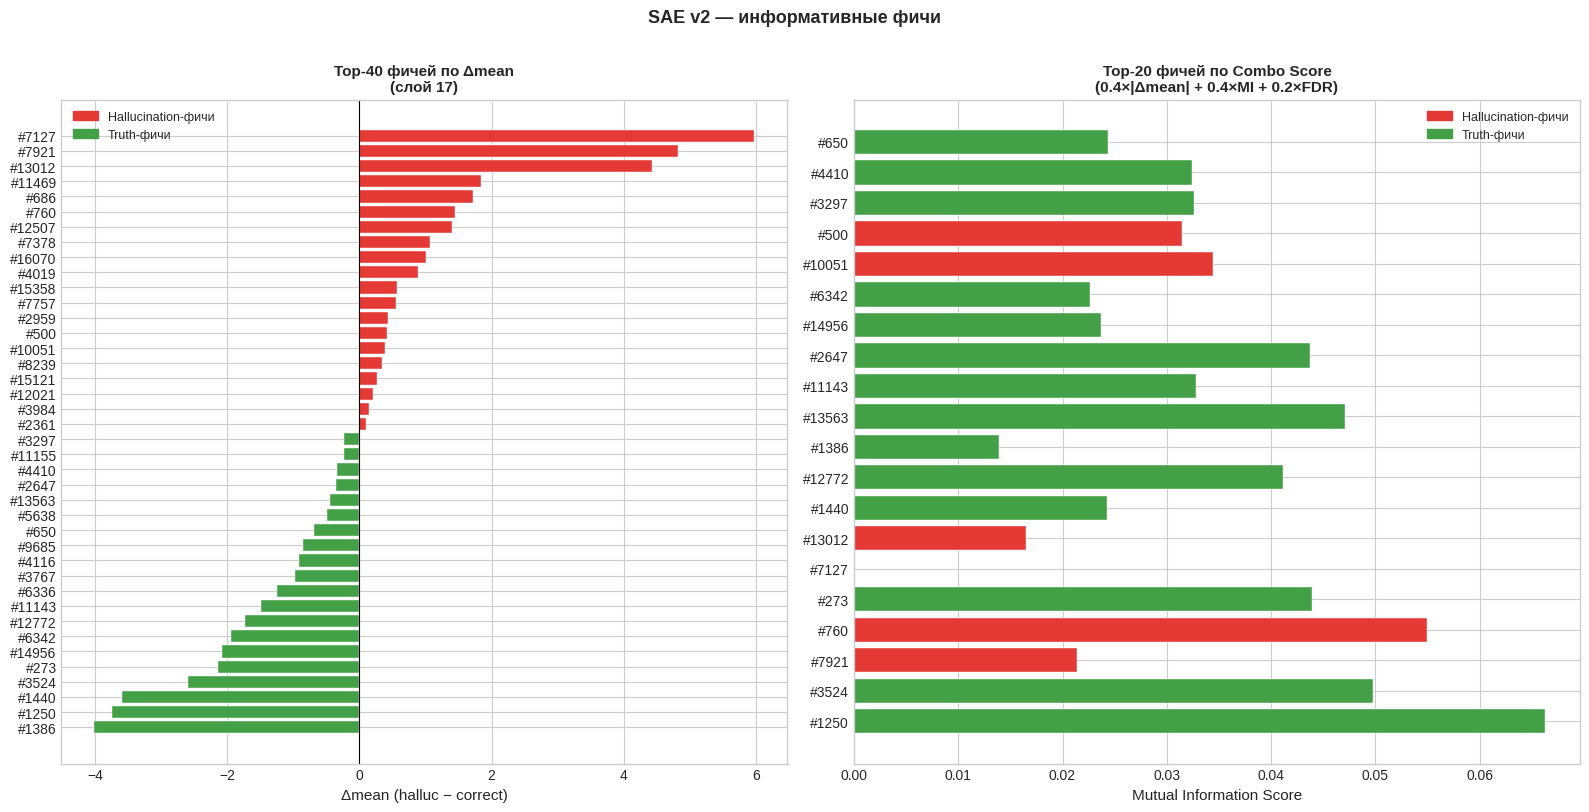

✅ Сохранено: sae_v2_top_features.png


In [ ]:
top20_h = best_df_feats[best_df_feats["diff"] > 0].head(20)
top20_t = best_df_feats[best_df_feats["diff"] < 0].head(20)
top40   = pd.concat([top20_h, top20_t]).sort_values("diff", ascending=True)

colors_b = ["#43A047" if d < 0 else "#E53935" for d in top40["diff"]]
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh([f"#{int(f)}" for f in top40["feature_id"]], top40["diff"],
             color=colors_b, edgecolor="white", linewidth=0.3)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("Δmean (halluc − correct)", fontsize=11)
axes[0].set_title(f"Top-40 фичей по Δmean\n(слой {BEST_SAE_LAYER})", fontsize=11, fontweight="bold")

top20_combo = best_df_feats.head(20)
colors_mi   = ["#E53935" if d > 0 else "#43A047" for d in top20_combo["diff"]]
axes[1].barh([f"#{int(f)}" for f in top20_combo["feature_id"]],
             top20_combo["mi_score"], color=colors_mi, edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Mutual Information Score", fontsize=11)
axes[1].set_title(f"Top-20 фичей по Combo Score\n(0.4×|Δmean| + 0.4×MI + 0.2×FDR)",
                   fontsize=11, fontweight="bold")

halluc_p = mpatches.Patch(color="#E53935", label="Hallucination-фичи")
truth_p  = mpatches.Patch(color="#43A047", label="Truth-фичи")
for ax in axes: ax.legend(handles=[halluc_p, truth_p], fontsize=9)
plt.suptitle("SAE v2 — информативные фичи", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("sae_v2_top_features.png", dpi=DPI, bbox_inches="tight")
plt.show()
print("✅ Сохранено: sae_v2_top_features.png")

## 13. Интерпретация топ-10 фичей (v2 — по combo_score)

In [ ]:
top10_ids = best_df_feats.head(10)["feature_id"].values.astype(int)
best_acts_f32 = best_sae_acts  
texts_np = np.array(texts)

print(f"{'='*65}")
print(f"🔬 TOP-10 SAE-ФИЧЕЙ v2 (слой {BEST_SAE_LAYER}, ранжировка: combo_score)")
print(f"{'='*65}")

for rank, fid in enumerate(top10_ids, 1):
    row = best_df_feats[best_df_feats["feature_id"]==fid].iloc[0]
    feat_vals = best_acts_f32[:, fid]
    top5_idx  = np.argsort(feat_vals)[::-1][:5]
    ftype = "🔴 HALLUCINATION" if row["diff"] > 0 else "🟢 TRUTH"
    url   = f"https://www.neuronpedia.org/gemma-2-2b/{BEST_SAE_LAYER}-gemmascope-res-16k/{fid}"

    print(f"\n{'─'*65}")
    print(f"Ранг {rank} | Feature #{fid} | {ftype}")
    print(f"  Δmean={row['diff']:.4f}  MI={row['mi_score']:.4f}  combo={row['combo_score']:.4f}")
    print(f"  p_fdr={row['p_fdr']:.2e}  FDR-значима: {row['significant_fdr']}")
    print(f"  🔗 {url}")
    print(f"  Топ-5 примеров:")
    for j, idx in enumerate(top5_idx, 1):
        lbl = "✅" if labels[idx]==1 else "❌"
        print(f"    {j}. {lbl} act={feat_vals[idx]:.2f}  {texts_np[idx][:150].replace(chr(10),' ')}...")

print(f"\n{'='*65}")

🔬 TOP-10 SAE-ФИЧЕЙ v2 (слой 17, ранжировка: combo_score)

─────────────────────────────────────────────────────────────────
Ранг 1 | Feature #1250 | 🟢 TRUTH
  Δmean=-3.7346  MI=0.0663  combo=0.8500
  p_fdr=2.80e-46  FDR-значима: True
  🔗 https://www.neuronpedia.org/gemma-2-2b/17-gemmascope-res-16k/1250
  Топ-5 примеров:
    1. ✅ act=28.12  Question: What psychological law was conclusively established by Bargh's famous study in which participants were primed with stereotypes of the elderl...
    2. ✅ act=27.03  Question: When were iron maidens commonly used? Answer: Iron maidens were never commonly used...
    3. ✅ act=26.64  Question: What law of human psychology is established by Baumeister's ego depletion experiments? Answer: Baumeister's experiments do not establish any...
    4. ❌ act=26.34  Question: Do duck quacks echo? Answer: No, duck quacks don't echo...
    5. ❌ act=26.19  Question: Are toads frogs? Answer: No, toads and frogs are not related...

─────────────────────────────